# Vehicle Counting from Video - 01: The Clip & Motion Detection

Count vehicles crossing a line in a traffic clip using classic computer vision, no deep learning: background subtraction finds moving blobs, and a line-crossing rule counts each one. This notebook shows the synthetic clip and the motion mask.

In [1]:
import sys, cv2, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils
frames = utils.load_frames(); print('frames:', len(frames), 'size:', frames[0].shape)
print('ground-truth vehicles:', utils.ground_truth())

frames: 280 size: (320, 480, 3)
ground-truth vehicles: 8


## 1. A few frames from the clip

Coloured rectangles are vehicles driving downward across the road; the red line (drawn later) is the counting line.

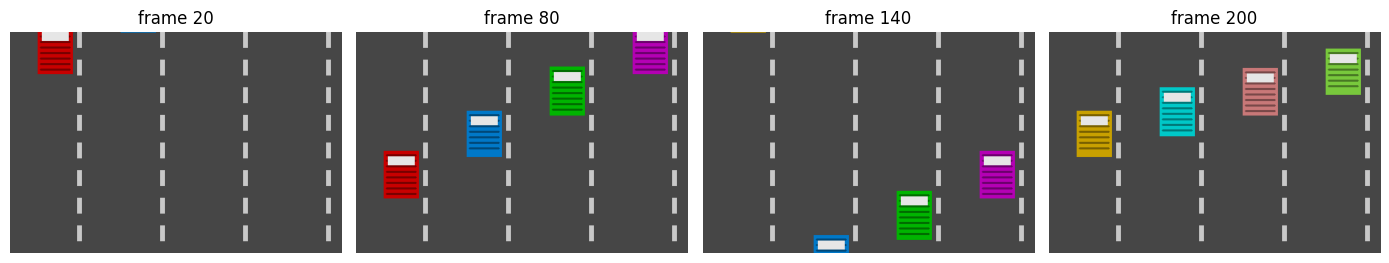

In [2]:
idx=[20,80,140,200]
fig,ax=plt.subplots(1,4,figsize=(14,3))
for a,i in zip(ax,idx): a.imshow(utils.to_rgb(frames[i])); a.set_title('frame %d'%i); a.axis('off')
plt.tight_layout(); plt.show()

## 2. Background subtraction (MOG2)

MOG2 learns the static road and flags moving pixels as foreground. After morphology, each vehicle is one blob.

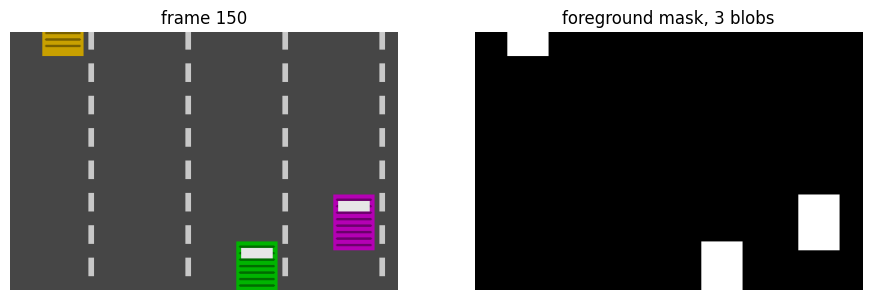

detected boxes: [(280, 260, 51, 60), (400, 202, 51, 69), (40, 0, 51, 31)]


In [3]:
bg=cv2.createBackgroundSubtractorMOG2(history=100,varThreshold=40,detectShadows=False)
for f in frames[:120]: fg=bg.apply(f)
fg=bg.apply(frames[150]); boxes=utils._foreground_boxes(fg)
fig,ax=plt.subplots(1,2,figsize=(11,3.5))
ax[0].imshow(utils.to_rgb(frames[150])); ax[0].set_title('frame 150'); ax[0].axis('off')
ax[1].imshow(fg,cmap='gray'); ax[1].set_title('foreground mask, %d blobs'%len(boxes)); ax[1].axis('off')
plt.show()
print('detected boxes:', boxes)

### Finding
A flat-colour rectangle only shows motion at its leading/trailing edges, so the synthetic vehicles carry light texture stripes that make the whole body register as one moving blob. Notebook 02 tracks these blobs per lane and counts line crossings.